<a href="https://colab.research.google.com/github/22F23057/health-risk-prediction/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#My dataset is available in googledrive; so I am accessing my drive from colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#Once this is executed, you will see your drive appearing on the left hand side

Mounted at /content/drive


In [5]:
# Define paths to the dataset
train_dir = '/content/drive/MyDrive/archive/PandasBears/Train'  # Update with your actual path
test_dir = '/content/drive/MyDrive/archive/PandasBears/Test'    # Update with your actual path

In [6]:
import os
print(len(os.listdir('/content/drive/MyDrive/archive/PandasBears/Train/Bears')))
print(len(os.listdir('/content/drive/MyDrive/archive/PandasBears/Train/Pandas')))
print(len(os.listdir('/content/drive/MyDrive/archive/PandasBears/Test/Bears')))
print(len(os.listdir('/content/drive/MyDrive/archive/PandasBears/Test/Pandas')))

250
250
50
50


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create ImageDataGenerator for training set
train_datagen = ImageDataGenerator(
    rescale=1./255, #normalisation / feature scaling
    validation_split=0.2  # Split 20% of the images for validation
)

# Load and prepare training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',  # 'binary' for binary classification (cats vs. dogs)
    subset='training'  # Specify 'training' for the training set
)

# Create ImageDataGenerator for validation set
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Note: Using the same validation split as in the training set
)

# Load and prepare validation data
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # Specify 'validation' for the validation set
)

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [9]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,UpSampling2D, Dropout

In [10]:
# create CNN model - custom-made

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))  #output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy']) #binary_crossentropy - binary classification

In [12]:
history = model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 146s 11s/step - accuracy: 0.7375 - loss: 0.7293 - val_accuracy: 1.0000 - val_loss: 0.0351
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 60s 5s/step - accuracy: 0.9850 - loss: 0.0557 - val_accuracy: 1.0000 - val_loss: 8.0401e-04
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 60s 5s/step - accuracy: 0.9975 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 3.1057e-04
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 60s 5s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 1.2175e-04
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 1.0000 - loss: 3.9825e-04 - val_accuracy: 1.0000 - val_loss: 4.4510e-05
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 1.0000 - loss: 3.5843e-04 - val_accuracy: 1.0000 - val_loss: 7.1990e-05
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 60s 5s/step - accuracy: 1.0000 - loss: 2.3316e-05 - val_accuracy: 1.0000 - val_loss: 2.6174e-05
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 60s 5s/step - accuracy: 1.0000 - loss: 1.0

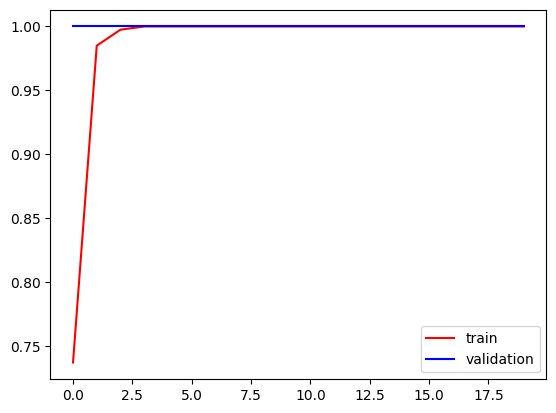

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

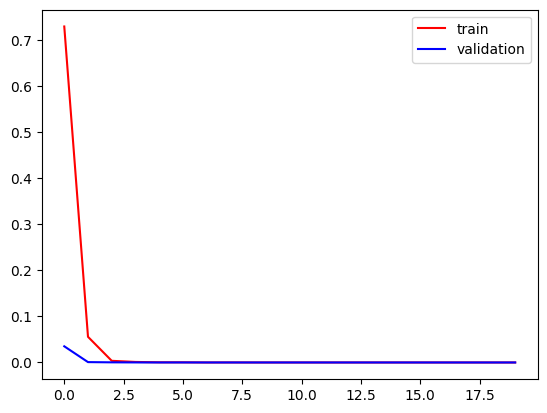

In [14]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [15]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 100 images belonging to 2 classes.


In [16]:
#predict the test data
predictions = model.predict(test_data)


4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step


In [17]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[21 29]
 [29 21]]
Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.42      0.42        50
           1       0.42      0.42      0.42        50

    accuracy                           0.42       100
   macro avg       0.42      0.42      0.42       100
weighted avg       0.42      0.42      0.42       100



In [18]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))  # 32 filters
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())  # added to reduce overfitting
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #feature reduction
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))  # added to reduce overfitting
model.add(Dense(1,activation='sigmoid'))  #output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
from keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [20]:
history = model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 94s 7s/step - accuracy: 0.9025 - loss: 2.5559 - val_accuracy: 0.7600 - val_loss: 0.7325
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 90s 7s/step - accuracy: 0.9950 - loss: 0.1677 - val_accuracy: 0.5000 - val_loss: 23.2536
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 91s 7s/step - accuracy: 0.9975 - loss: 0.0263 - val_accuracy: 0.5000 - val_loss: 46.7289
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 91s 7s/step - accuracy: 1.0000 - loss: 1.0563e-31 - val_accuracy: 0.5000 - val_loss: 40.6110
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 90s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 40.2949
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 92s 7s/step - accuracy: 1.0000 - loss: 4.7148e-18 - val_accuracy: 0.5000 - val_loss: 42.1117
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 141s 7s/step - accuracy: 1.0000 - loss: 2.1942e-16 - val_accuracy: 0.5000 - val_loss: 44.0577
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 90s 7s/step - accuracy: 1.0000 - loss: 3.0929e-08 - val_a

In [21]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary'
)

Found 100 images belonging to 2 classes.


In [22]:
predictions = model.predict(test_data)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 904ms/step


In [23]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[ 1 49]
 [ 4 46]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.20      0.02      0.04        50
           1       0.48      0.92      0.63        50

    accuracy                           0.47       100
   macro avg       0.34      0.47      0.34       100
weighted avg       0.34      0.47      0.34       100



In [24]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten

resnet_model = Sequential()    #ResNet50 is a pre-trained model
pretrained_model = tf.keras.applications.ResNet50(include_top = False, #because i have my own image of a diff dimension
                                                input_shape = (256,256,3),
                                                pooling = 'max', classes = 2,
                                                weights = 'imagenet')
for layer in pretrained_model.layers:
    layer.trainable = False  #all layers in the Resnet50 is not trainable; keep those weights; I am going to add my own i/p and other layers

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation = 'relu'))
resnet_model.add(Dense(1, activation = 'sigmoid'))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [25]:
from keras.optimizers import Adam
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [26]:
history = resnet_model.fit(train_data, epochs=20, validation_data=validation_data)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 119s 9s/step - accuracy: 0.5400 - loss: 2.7658 - val_accuracy: 0.8300 - val_loss: 0.5589
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 109s 9s/step - accuracy: 0.8225 - loss: 0.5005 - val_accuracy: 0.9100 - val_loss: 0.1632
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 110s 8s/step - accuracy: 0.9475 - loss: 0.1568 - val_accuracy: 0.9200 - val_loss: 0.1967
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 140s 8s/step - accuracy: 0.9675 - loss: 0.0779 - val_accuracy: 0.9900 - val_loss: 0.0533
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 129s 10s/step - accuracy: 0.9825 - loss: 0.0547 - val_accuracy: 0.9900 - val_loss: 0.0459
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 108s 8s/step - accuracy: 0.9800 - loss: 0.0460 - val_accuracy: 1.0000 - val_loss: 0.0297
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 110s 8s/step - accuracy: 0.9825 - loss: 0.0412 - val_accuracy: 0.9800 - val_loss: 0.0684
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 109s 9s/step - accuracy: 0.9825 - loss: 0.0428 - val_accuracy: 0.9900 - 

In [27]:
predictions = resnet_model.predict(test_data)

3/4 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step


In [28]:
from sklearn.metrics import confusion_matrix, classification_report

# Assuming you have ground truth labels (true_labels) and predicted labels (predictions)
true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)  # Adjust the threshold as needed

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Print classification report
print("Classification Report after applying techniques to handle overfitting:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[24 26]
 [25 25]]
Classification Report after applying techniques to handle overfitting:
              precision    recall  f1-score   support

           0       0.49      0.48      0.48        50
           1       0.49      0.50      0.50        50

    accuracy                           0.49       100
   macro avg       0.49      0.49      0.49       100
weighted avg       0.49      0.49      0.49       100

